# Stationarity & Diagnostics

Module 3. Simulated series where the truth is known, then the same tools on the bakery data from [EDA.ipynb](EDA.ipynb).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.adfvalues import mackinnonp, mackinnoncrit
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.dates as mdates

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

rng = np.random.default_rng(42)
N = 500

## 1. What is stationarity, and why it matters

**Intuition:** a series is stationary if a window of it looks statistically the same wherever you slide the window. No drifting level, no growing spread, no calendar-dependent behaviour. Show someone a chunk with the x-axis labels removed and they cannot tell you *when* it came from.

Formally, weak (covariance) stationarity requires three things, for all $t$:

$$\mathbb{E}[y_t] = \mu \qquad \text{Var}(y_t) = \sigma^2 < \infty \qquad \text{Cov}(y_t, y_{t+k}) = \gamma_k \ \ \text{(depends on } k \text{ only, not } t)$$

**Why it matters:** ARMA models estimate *one* $\mu$, *one* $\sigma^2$ and *one* set of $\gamma_k$. If those quantities move over time, the estimates describe no period in particular. Two concrete consequences:

- **Spurious regression** — two independent random walks regress on each other with $R^2 \approx 0.9$ and huge $t$-statistics. The relationship is entirely fake.
- **Invalid inference** — standard errors, $t$-tests and confidence intervals assume stationarity. Under a unit root the usual distributions no longer apply.

**Four ways to fail** (one per panel below): trend in the mean, variance growing with level, seasonality, and a structural break.

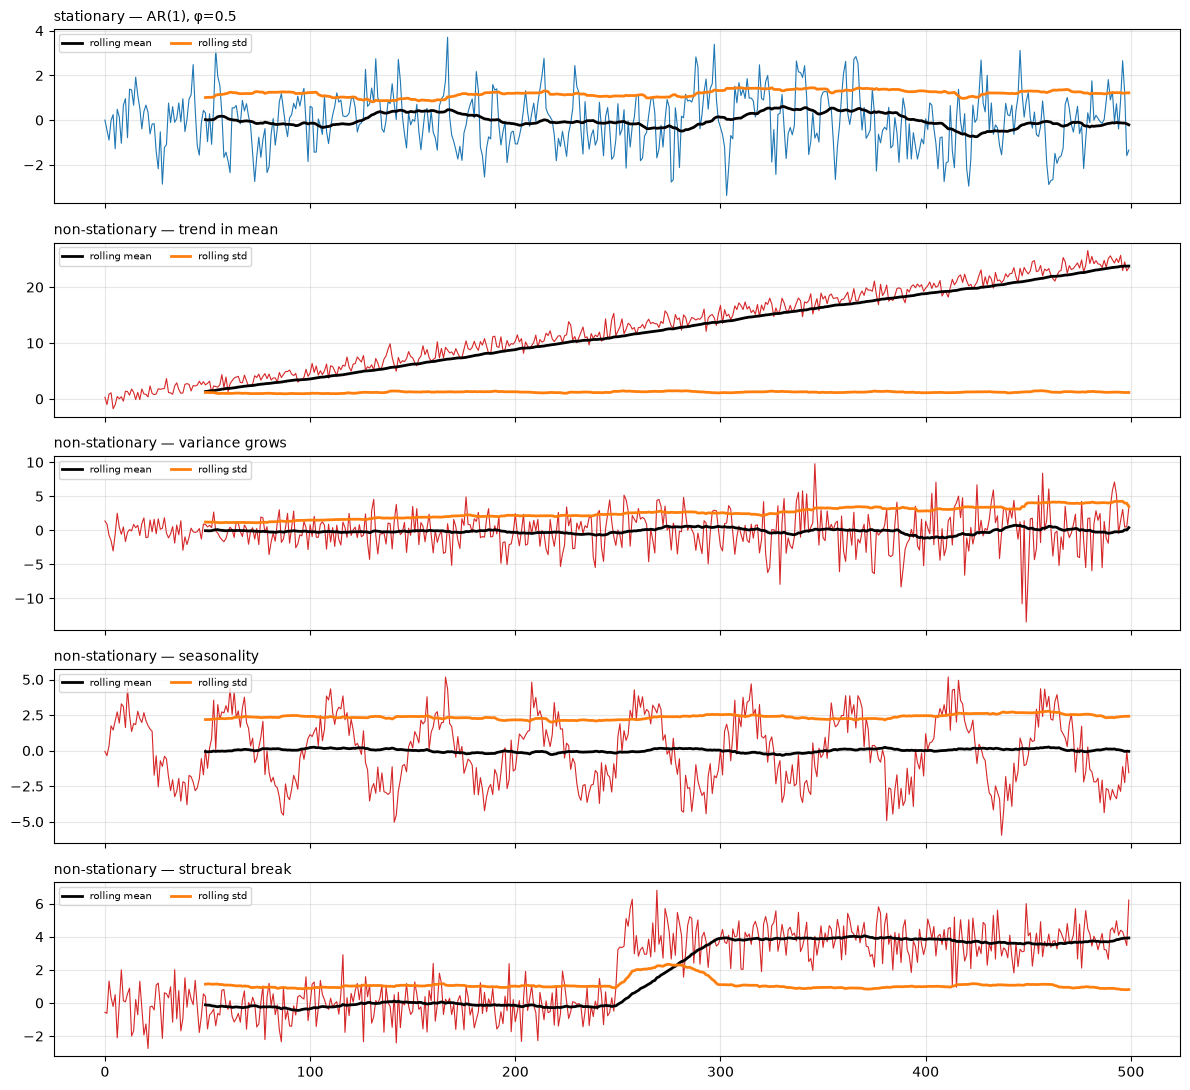

In [2]:
t = np.arange(N)

examples = {
    "stationary — AR(1), φ=0.5": None,
    "non-stationary — trend in mean": 0.05 * t + rng.normal(size=N),
    "non-stationary — variance grows": rng.normal(size=N) * (1 + 3 * t / N),
    "non-stationary — seasonality": 3 * np.sin(2 * np.pi * t / 50) + rng.normal(size=N),
    "non-stationary — structural break": np.r_[rng.normal(0, 1, N // 2), rng.normal(4, 1, N // 2)],
}
ar1 = np.zeros(N)
for i in range(1, N):
    ar1[i] = 0.5 * ar1[i - 1] + rng.normal()
examples["stationary — AR(1), φ=0.5"] = ar1

fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True)
for ax, (name, x) in zip(axes, examples.items()):
    ax.plot(x, lw=0.8, color="tab:blue" if name.startswith("stationary") else "tab:red")
    # rolling mean/std make the failure visible
    s = pd.Series(x)
    ax.plot(s.rolling(50).mean(), lw=2, color="black", label="rolling mean")
    ax.plot(s.rolling(50).std(), lw=2, color="tab:orange", label="rolling std")
    ax.set_title(name, loc="left", fontsize=10)
    ax.legend(fontsize=7, loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

The black and orange lines are the diagnostic: **stationary means both are flat.** Panel 1 they are; panels 2-5 one or both wander.

## 2. Strict vs weak (covariance) stationarity

| | Strict | Weak / covariance |
|---|---|---|
| Condition | the **full joint distribution** of $(y_{t_1},\dots,y_{t_k})$ is unchanged by a time shift | only the **first two moments** are constant |
| Formally | $F(y_{t_1},\dots,y_{t_k}) = F(y_{t_1+h},\dots,y_{t_k+h})$ | $\mathbb{E}[y_t]=\mu$, $\text{Var}(y_t)=\sigma^2$, $\text{Cov}(y_t,y_{t+k})=\gamma_k$ |
| Constrains | every moment, skew, tail behaviour | mean, variance, autocovariance |
| In practice | untestable, rarely assumed | what "stationary" means in ARIMA |

Relationships worth knowing:

- Strict **+ finite variance** $\Rightarrow$ weak. Strict alone does not (a Cauchy i.i.d. series is strictly stationary with no finite variance).
- Weak $\not\Rightarrow$ strict in general — but for a **Gaussian** process the two coincide, because a Gaussian distribution is fully determined by its first two moments.
- Everything below tests **weak** stationarity. It is the practical notion.

## 3. White noise and the random walk

The two reference processes. Everything else is understood relative to them.

**White noise** — no structure at all:

$$\varepsilon_t \sim \text{iid}(0, \sigma^2), \qquad \gamma_k = 0 \ \ \forall k \neq 0$$

Stationary by construction. It is both the **null hypothesis for residuals** (a good model leaves nothing behind) and the ceiling on predictability (nothing to forecast).

**Random walk** — the cumulative sum of white noise:

$$y_t = y_{t-1} + \varepsilon_t = \sum_{i=1}^{t} \varepsilon_i$$

$$\mathbb{E}[y_t] = 0 \quad\text{(constant)} \qquad \text{Var}(y_t) = t\sigma^2 \quad\text{(grows without bound)}$$

The mean is fine; the **variance is not**, so it is non-stationary. Key properties:

- **Shocks are permanent.** $\partial y_{t+h} / \partial \varepsilon_t = 1$ for every $h$ — a shock never decays.
- The best forecast is $\hat{y}_{T+h} = y_T$ (the naive forecast), and intervals widen as $\sqrt{h}$.
- $\Delta y_t = \varepsilon_t$ — one difference makes it white noise. This is what "difference-stationary" means.
- Adding a constant gives a **random walk with drift**, $y_t = \mu + y_{t-1} + \varepsilon_t$, which trends stochastically.

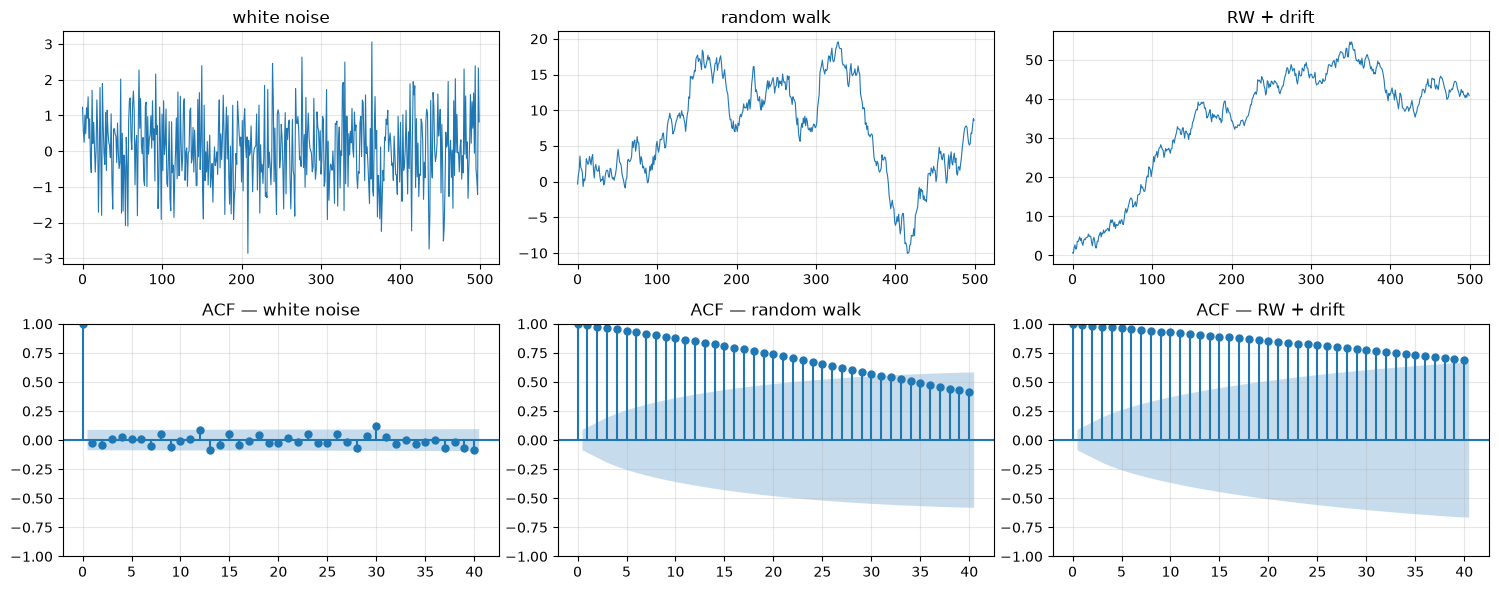

Var(y_t) at t = 100, 250, 500: [np.float64(98.2), np.float64(243.8), np.float64(492.8)]  (theory: t·σ² = t)


In [3]:
wn    = rng.normal(size=N)
rw    = np.cumsum(rng.normal(size=N))
rw_d  = np.cumsum(0.1 + rng.normal(size=N))

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for j, (name, x) in enumerate([("white noise", wn), ("random walk", rw), ("RW + drift", rw_d)]):
    axes[0, j].plot(x, lw=0.8)
    axes[0, j].set_title(name)
    plot_acf(x, lags=40, ax=axes[1, j])
    axes[1, j].set_title(f"ACF — {name}")
plt.tight_layout()
plt.show()

# variance of a random walk grows linearly in t — average over many paths
paths = np.cumsum(rng.normal(size=(2000, N)), axis=1)
print("Var(y_t) at t = 100, 250, 500:",
      [round(paths[:, k - 1].var(), 1) for k in (100, 250, 500)], " (theory: t·σ² = t)")

**The correlogram signature.** White noise: everything inside the band. Random walk: near-1 autocorrelation decaying *linearly*, not exponentially — that slow linear decay is the visual fingerprint of a unit root.

## 4. Autocovariance, autocorrelation, PACF, correlogram

**Autocovariance** at lag $k$ — covariance of the series with its own past:

$$\gamma_k = \text{Cov}(y_t, y_{t-k}) = \mathbb{E}[(y_t - \mu)(y_{t-k} - \mu)]$$

Scale-dependent, so we normalise. **Autocorrelation (ACF)**:

$$\rho_k = \frac{\gamma_k}{\gamma_0}, \qquad \rho_0 = 1, \qquad -1 \le \rho_k \le 1$$

$\gamma_0 = \text{Var}(y_t)$. The **correlogram** is simply the plot of $\rho_k$ against $k$, with the band $\pm 1.96/\sqrt{T}$ marking where a correlation is indistinguishable from zero.

**Partial autocorrelation (PACF)** — the correlation between $y_t$ and $y_{t-k}$ **after removing** the effect of the intervening lags $1,\dots,k-1$:

$$\phi_{kk} = \text{Corr}\big(y_t - \hat{y}_t^{(k-1)},\ y_{t-k} - \hat{y}_{t-k}^{(k-1)}\big)$$

It is the coefficient on $y_{t-k}$ in a regression of $y_t$ on all $k$ lags. Why it is needed: if $y_t$ depends only on $y_{t-1}$, then $y_t$ and $y_{t-2}$ are still correlated *through* $y_{t-1}$. The ACF shows that indirect echo; the PACF removes it.

**Identification table:**

| Process | ACF | PACF |
|---|---|---|
| AR($p$) | tails off (exponential / sinusoidal) | **cuts off after lag $p$** |
| MA($q$) | **cuts off after lag $q$** | tails off |
| ARMA($p,q$) | tails off | tails off |
| Random walk | decays slowly and linearly | large spike at lag 1 only |
| White noise | all zero | all zero |

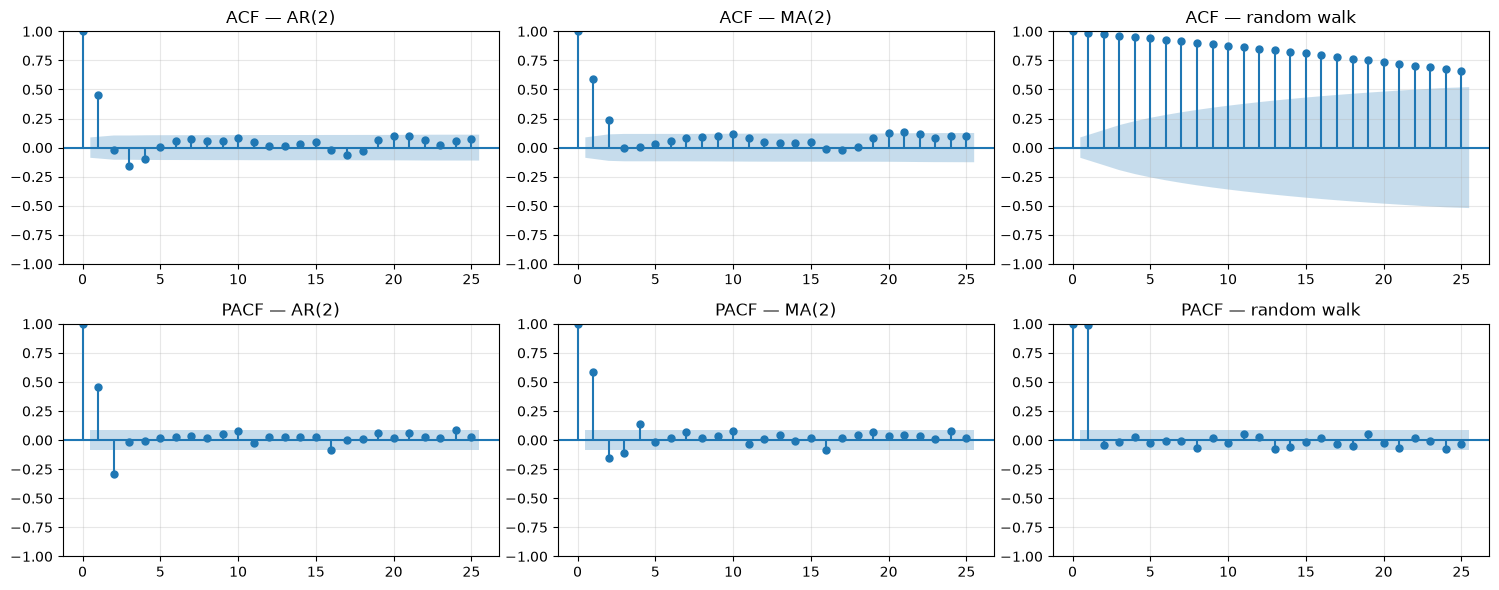

AR(2): PACF should cut off after lag 2
  pacf[1:4] = [ 0.455 -0.292 -0.014]
MA(2): ACF should cut off after lag 2
  acf[1:4]  = [ 0.587  0.241 -0.002]

significance band for T=500: ±0.088


In [4]:
ar2 = np.zeros(N); ma2 = np.zeros(N)
e = rng.normal(size=N)
for i in range(2, N):
    ar2[i] = 0.6 * ar2[i - 1] - 0.3 * ar2[i - 2] + e[i]     # AR(2)
    ma2[i] = e[i] + 0.7 * e[i - 1] + 0.4 * e[i - 2]         # MA(2)

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for j, (name, x) in enumerate([("AR(2)", ar2), ("MA(2)", ma2), ("random walk", rw)]):
    plot_acf(x, lags=25, ax=axes[0, j]);  axes[0, j].set_title(f"ACF — {name}")
    plot_pacf(x, lags=25, ax=axes[1, j], method="ywm"); axes[1, j].set_title(f"PACF — {name}")
plt.tight_layout()
plt.show()

print("AR(2): PACF should cut off after lag 2")
print("  pacf[1:4] =", np.round(pacf(ar2, nlags=3, method="ywm")[1:4], 3))
print("MA(2): ACF should cut off after lag 2")
print("  acf[1:4]  =", np.round(acf(ma2, nlags=3)[1:4], 3))
print(f"\nsignificance band for T={N}: ±{1.96/np.sqrt(N):.3f}")

Read the panels against the table: AR(2) PACF dies after lag 2, MA(2) ACF dies after lag 2, random-walk ACF crawls down linearly.

## 5. Unit roots; deterministic vs stochastic trend

Write an AR(1) as $y_t = \phi y_{t-1} + \varepsilon_t$. In lag-polynomial form $(1 - \phi B)y_t = \varepsilon_t$, whose root is $B = 1/\phi$. Behaviour is decided entirely by $|\phi|$:

| $\phi$ | Root | Behaviour | Shock at time $t$ |
|---|---|---|---|
| $\lvert\phi\rvert < 1$ | outside unit circle | stationary, mean-reverting | decays as $\phi^h$ |
| $\phi = 1$ | **on** the unit circle — a **unit root** | random walk, non-stationary | **permanent** |
| $\lvert\phi\rvert > 1$ | inside | explosive | amplifies |

"Unit root" therefore just means $\phi = 1$: the series has no force pulling it back, so it wanders. Note $\phi = 0.95$ and $\phi = 1.0$ look nearly identical in a short sample — which is exactly why unit-root tests have low power.

**The two kinds of trend** — visually similar, statistically opposite:

$$\text{deterministic: } y_t = \alpha + \beta t + \varepsilon_t
\qquad
\text{stochastic: } y_t = \mu + y_{t-1} + \varepsilon_t$$

| | Deterministic (trend-stationary) | Stochastic (difference-stationary) |
|---|---|---|
| Trend is | a fixed function of time | accumulated shocks |
| Shocks | temporary — reverts to the line | permanent — the path is shifted forever |
| Long-run forecast | back to the trend line | last value + drift |
| Correct fix | **detrend** (regress on $t$) | **difference** |
| Wrong fix costs | differencing induces a spurious MA(1) | detrending leaves the unit root in place |

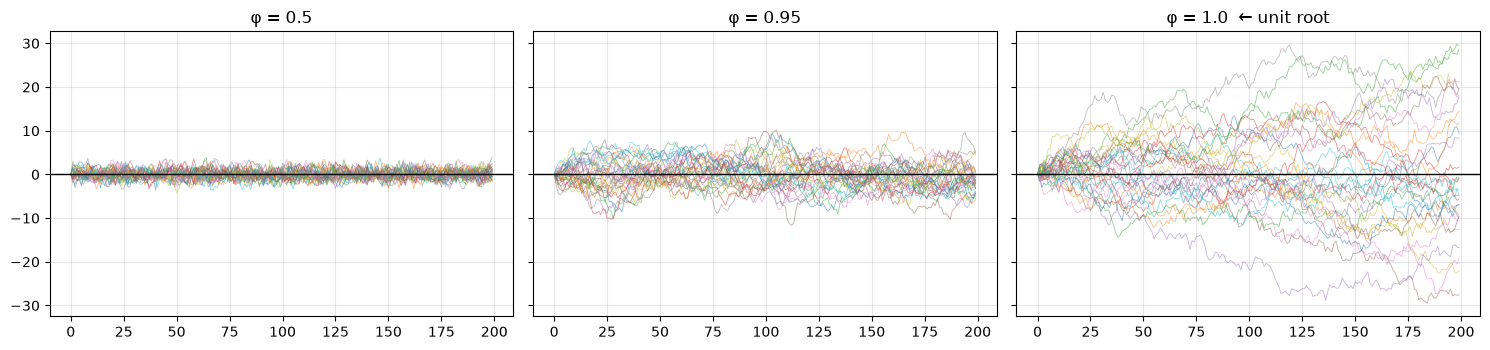

φ= 0.5: shock remaining after 10 steps = 0.001, after 50 = 0.000
φ=0.95: shock remaining after 10 steps = 0.599, after 50 = 0.077
φ= 1.0: shock remaining after 10 steps = 1.000, after 50 = 1.000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, phi in zip(axes, [0.5, 0.95, 1.0]):
    for _ in range(30):
        x = np.zeros(200)
        for i in range(1, 200):
            x[i] = phi * x[i - 1] + rng.normal()
        ax.plot(x, lw=0.6, alpha=0.5)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"φ = {phi}" + ("  ← unit root" if phi == 1.0 else ""))
plt.tight_layout()
plt.show()

# how long a shock survives
for phi in [0.5, 0.95, 1.0]:
    print(f"φ={phi:4}: shock remaining after 10 steps = {phi**10:.3f}, after 50 = {phi**50:.3f}")

At $\phi=0.5$ the paths hug zero; at $\phi=0.95$ they wander far but still return; at $\phi=1$ they never return. **A shock retains 60% of its size after 10 periods when $\phi=0.95$, and 100% forever when $\phi=1$.**

## 6. Trend-stationary vs difference-stationary: the 2x2

The point of the whole module. Two series that look alike, two fixes, and applying the wrong one leaves you worse off.

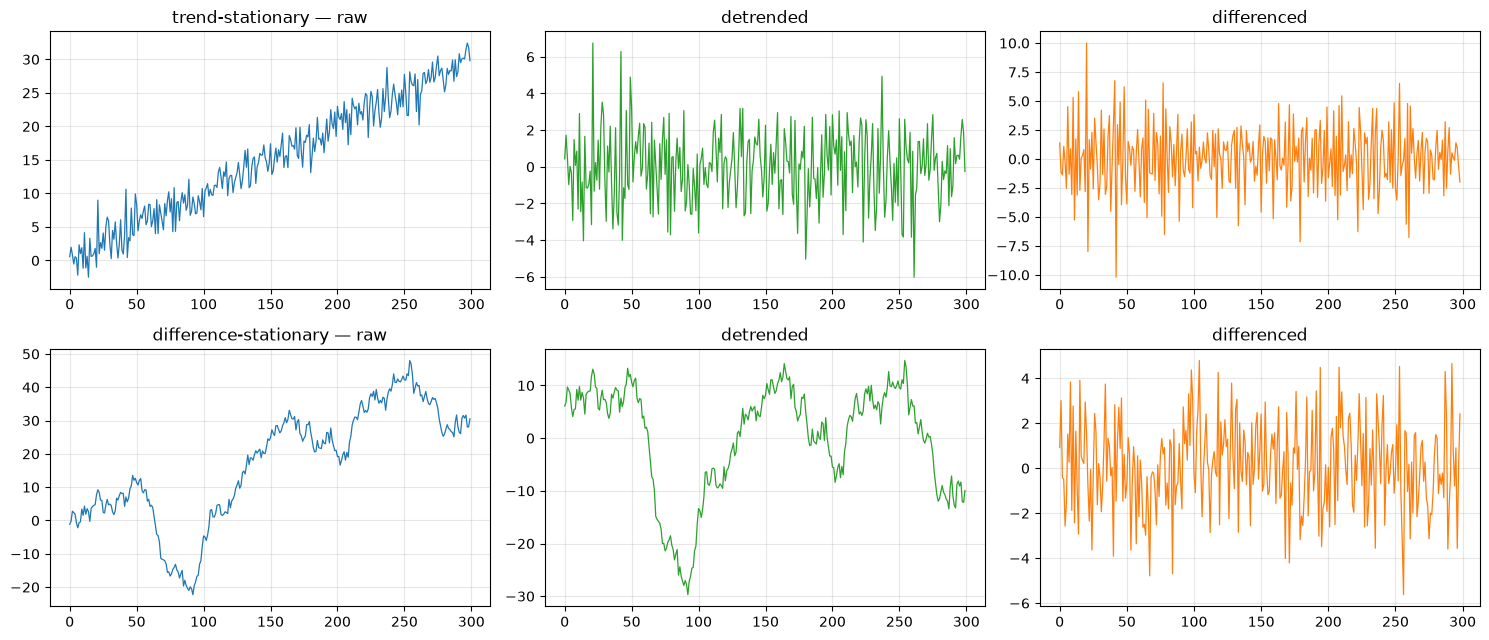

,series,treatment,ADF p,std,resid acf(1)
0,trend-stationary,raw,0.9594,8.875,0.940
1,trend-stationary,detrended,0.0000,1.938,-0.076
2,trend-stationary,differenced,0.0000,2.847,-0.510
3,difference-stationary,raw,0.7208,17.277,0.991
4,difference-stationary,detrended,0.1906,10.377,0.980
5,difference-stationary,differenced,0.0000,1.967,-0.014


In [6]:
n = 300
tt = np.arange(n)
ts_series = 0.1 * tt + rng.normal(size=n) * 2          # deterministic trend
ds_series = np.cumsum(0.1 + rng.normal(size=n) * 2)    # stochastic trend (RW + drift)

def detrend(x):
    return sm.OLS(x, sm.add_constant(np.arange(len(x)))).fit().resid

fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
for i, (name, x) in enumerate([("trend-stationary", ts_series), ("difference-stationary", ds_series)]):
    axes[i, 0].plot(x, lw=0.9); axes[i, 0].set_title(f"{name} — raw")
    axes[i, 1].plot(detrend(x), lw=0.9, color="tab:green"); axes[i, 1].set_title("detrended")
    axes[i, 2].plot(np.diff(x), lw=0.9, color="tab:orange"); axes[i, 2].set_title("differenced")
plt.tight_layout()
plt.show()

rows = []
for name, x in [("trend-stationary", ts_series), ("difference-stationary", ds_series)]:
    for fix, z in [("raw", x), ("detrended", detrend(x)), ("differenced", np.diff(x))]:
        rows.append({"series": name, "treatment": fix,
                     "ADF p": round(adfuller(z, autolag="AIC")[1], 4),
                     "std": round(np.std(z), 3),
                     "resid acf(1)": round(acf(z, nlags=1)[1], 3)})
pd.DataFrame(rows)

**The diagonal is what matters.**

- Trend-stationary + **detrend** → stationary, clean.
- Trend-stationary + **difference** → also passes ADF, but look at `resid acf(1)`: it goes strongly **negative** (~-0.5). That is the signature of **over-differencing** — an artificial MA(1) that you now have to model away.
- Difference-stationary + **detrend** → ADF still fails to reject. Removing a straight line does nothing to a unit root; the wander is in the shocks, not in a line.
- Difference-stationary + **difference** → stationary, clean.

→ Diagnose which trend you have *before* choosing the fix. A negative lag-1 residual autocorrelation near -0.5 is the tell that you differenced something you should have detrended.

## 7. Log vs detrend vs difference — on the bakery series

Three tools, three different jobs:

| Tool | Fixes | Leaves alone |
|---|---|---|
| **Log** | non-constant **variance**, multiplicative seasonality | the mean/trend |
| **Detrend** | a **deterministic** trend in the mean | variance, stochastic trend |
| **Difference** | a **stochastic** trend / unit root | non-constant variance |

They compose: on data whose variance grows with level *and* which has a unit root, take logs **first**, then difference.

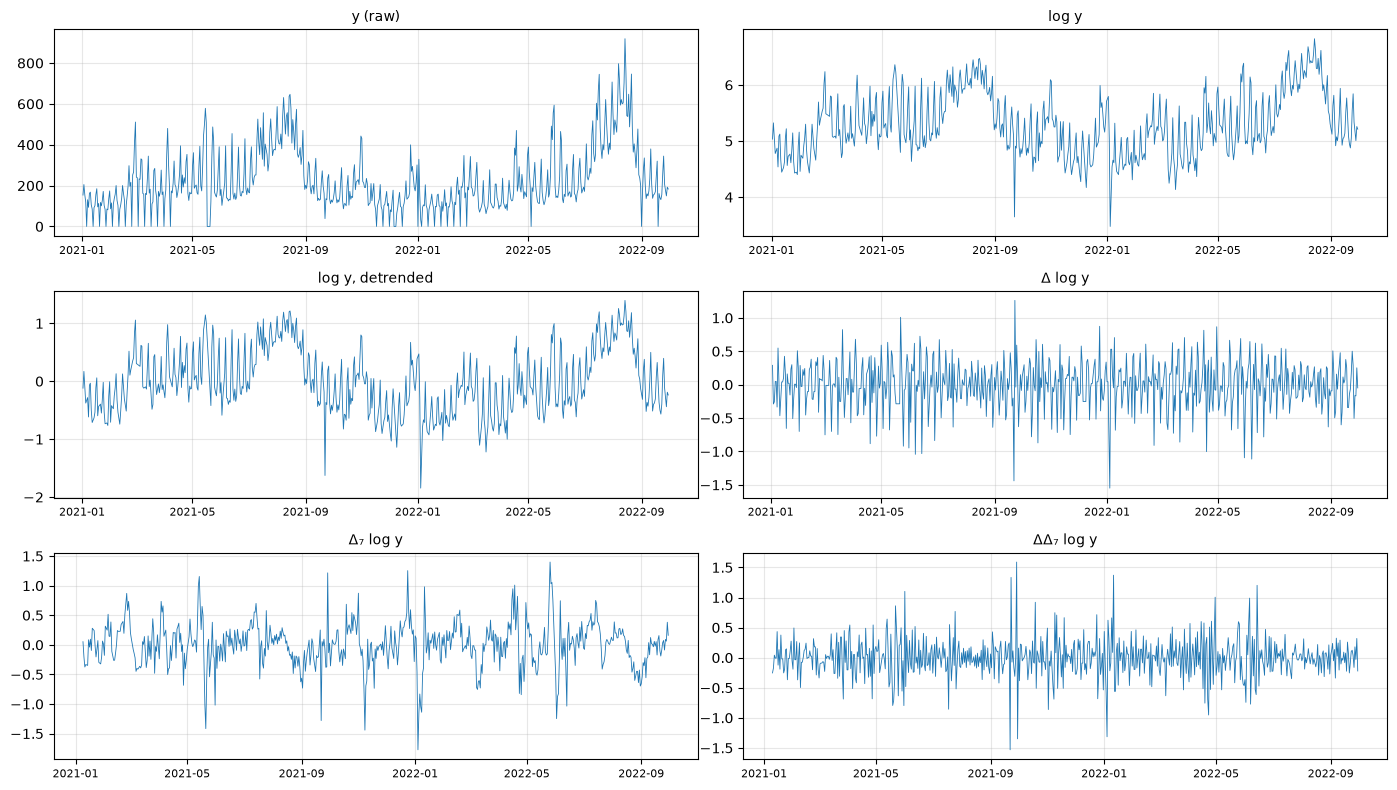

In [7]:
bakery = pd.read_csv("../data/daily_sales_french_bakery.csv", parse_dates=["ds"])
y = (bakery[bakery["unique_id"] == "TRADITIONAL BAGUETTE"]
     .sort_values("ds").set_index("ds")["y"].asfreq("D"))

log_y = np.log(y.where(y > 0)).interpolate()      # closures -> NaN -> interpolated
lin   = sm.OLS(log_y.values, sm.add_constant(np.arange(len(log_y)))).fit()
detr  = pd.Series(lin.resid, index=log_y.index)

variants = {
    "y (raw)":              y,
    "log y":                log_y,
    "log y, detrended":     detr,
    "Δ log y":              log_y.diff(),
    "Δ₇ log y":             log_y.diff(7),
    "ΔΔ₇ log y":            log_y.diff(7).diff(),
}

fig, axes = plt.subplots(3, 2, figsize=(14, 8))
for ax, (name, v) in zip(axes.ravel(), variants.items()):
    ax.plot(v.index, v.values, lw=0.6)
    ax.set_title(name, fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

## 8. The tests: DF, ADF, KPSS, PP

### Dickey-Fuller
Start from $y_t = \phi y_{t-1} + \varepsilon_t$ and subtract $y_{t-1}$:

$$\Delta y_t = (\phi - 1) y_{t-1} + \varepsilon_t = \delta y_{t-1} + \varepsilon_t$$

Test $H_0: \delta = 0$ (i.e. $\phi = 1$, unit root) against $H_1: \delta < 0$ (stationary). The catch: under $H_0$ the $t$-statistic does **not** follow a $t$-distribution, so it is compared against **Dickey-Fuller critical values** instead.

### Augmented Dickey-Fuller (ADF)
Plain DF assumes the errors are white noise. Real series have short-run dynamics, so ADF adds $p$ lagged differences to soak them up:

$$\Delta y_t = \alpha + \beta t + \delta y_{t-1} + \sum_{i=1}^{p} \theta_i \Delta y_{t-i} + \varepsilon_t$$

$p$ is chosen by AIC (`autolag="AIC"`). Include $\alpha$/$\beta t$ via `regression=` — `"c"` for a level, `"ct"` if a deterministic trend is plausible.

### KPSS
The **complementary** test, with the hypotheses **reversed**. It decomposes the series into a deterministic trend, a random walk, and noise, and tests whether the random-walk variance is zero:

$$H_0: \text{stationary (or trend-stationary)} \qquad H_1: \text{unit root}$$

So $p < 0.05$ means **reject stationarity**. Getting this backwards is the single most common mistake with KPSS.

### Phillips-Perron (PP)
Same null as ADF, but instead of adding lags it corrects the DF statistic **non-parametrically** for autocorrelation and heteroscedasticity, using a Newey-West long-run variance $\hat{\lambda}^2$:

$$Z_\tau = \sqrt{\tfrac{s^2}{\hat{\lambda}^2}}\, \tau - \frac{(\hat{\lambda}^2 - s^2)\, n\, \text{se}(\hat{\delta})}{2 \hat{\lambda}^2 \hat{\sigma}}$$

Robust to heteroscedasticity and needs no lag choice, but performs worse than ADF in small samples with strong MA terms.

| Test | $H_0$ | $H_1$ | $p < 0.05$ means |
|---|---|---|---|
| ADF | unit root | stationary | **stationary** |
| PP | unit root | stationary | **stationary** |
| KPSS | stationary | unit root | **non-stationary** |

`statsmodels` has no Phillips-Perron, so it is implemented below — it is short, and it makes the contrast with ADF explicit. (In production use `arch.unitroot.PhillipsPerron`.)

In [8]:
def phillips_perron(x, lags=None, regression="c"):
    '''Phillips-Perron Z_tau test. H0: unit root. Returns (stat, pvalue, crit, lags).'''
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    dy, ylag = np.diff(x), x[:-1]
    n = len(dy)

    X = ylag.reshape(-1, 1)
    if regression in ("c", "ct"):
        X = np.column_stack([np.ones(n), X])
    if regression == "ct":
        X = np.column_stack([X, np.arange(1, n + 1)])

    res = sm.OLS(dy, X).fit()
    k = 1 if regression in ("c", "ct") else 0
    delta, se = res.params[k], res.bse[k]
    tau = delta / se
    u = res.resid

    if lags is None:                                  # Newey-West bandwidth
        lags = int(np.floor(4 * (n / 100) ** 0.25))

    s2 = (u @ u) / n
    lam2 = s2
    for j in range(1, lags + 1):                      # Bartlett kernel
        lam2 += 2 * (1 - j / (lags + 1)) * (u[j:] @ u[:-j]) / n

    sigma2 = s2 * n / res.df_resid
    stat = np.sqrt(s2 / lam2) * tau - (lam2 - s2) * n * se / (2 * lam2 * np.sqrt(sigma2))

    return (stat, mackinnonp(stat, regression=regression, N=1),
            dict(zip(["1%", "5%", "10%"], mackinnoncrit(N=1, regression=regression, nobs=n))), lags)


# sanity check against known processes
for name, x in [("white noise", wn), ("random walk", rw), ("AR(1) φ=0.5", ar1)]:
    pp = phillips_perron(x)
    ad = adfuller(x, autolag="AIC")
    print(f"{name:14s} PP Z={pp[0]:8.3f} p={pp[1]:.4g}   |   ADF={ad[0]:8.3f} p={ad[1]:.4g}")

white noise    PP Z= -22.820 p=0   |   ADF= -22.811 p=0
random walk    PP Z=  -1.876 p=0.3436   |   ADF=  -1.810 p=0.3754
AR(1) φ=0.5    PP Z= -12.073 p=2.326e-22   |   ADF=  -6.569 p=8.031e-09


In [9]:
def stationarity_report(series, name, regression="c"):
    '''Run ADF, PP and KPSS together and state the verdict of each.'''
    x = pd.Series(series).dropna().values
    adf_stat, adf_p = adfuller(x, autolag="AIC", regression=regression)[:2]
    pp_stat, pp_p, _, _ = phillips_perron(x, regression=regression)
    kpss_stat, kpss_p = kpss(x, regression=regression, nlags="auto")[:2]
    return {
        "series": name,
        "ADF p": round(adf_p, 4),   "ADF says":  "stationary" if adf_p  < 0.05 else "unit root",
        "PP p":  round(pp_p, 4),    "PP says":   "stationary" if pp_p   < 0.05 else "unit root",
        "KPSS p": round(kpss_p, 4), "KPSS says": "non-stat"   if kpss_p < 0.05 else "stationary",
    }

pd.DataFrame([stationarity_report(v, k) for k, v in variants.items()])

,series,ADF p,ADF says,PP p,PP says,KPSS p,KPSS says
0,y (raw),0.0470,stationary,0.0000,stationary,0.0743,stationary
1,log y,0.1121,unit root,0.9803,unit root,0.0959,stationary
2,"log y, detrended",0.1201,unit root,0.9610,unit root,0.1000,stationary
3,Δ log y,0.0000,stationary,1.0000,unit root,0.1000,stationary
4,Δ₇ log y,0.0000,stationary,0.0000,stationary,0.1000,stationary
5,ΔΔ₇ log y,0.0000,stationary,0.0000,stationary,0.1000,stationary


**Reading the bakery results**

- **`y (raw)`: ADF p = 0.047 rejects the unit root, KPSS p = 0.074 fails to reject stationarity.** Both nominally say "stationary" — yet the EDA showed the rolling mean running from 89 to 579. The tests are being fooled by strong seasonality, which mimics mean reversion. **A test result that contradicts the plot is a reason to distrust the test, not the plot.**
- **`log y`: ADF p = 0.112 (unit root), KPSS p = 0.096 (stationary).** Neither rejects — the low-power quadrant. Inconclusive, not evidence of anything.
- **Detrending barely moves it** (ADF p = 0.120). That is the section-6 lesson on real data: the wander is **stochastic and seasonal**, not a deterministic line, so removing a line achieves nothing.
- **Differencing settles it decisively**: $\Delta \log y$ p ≈ 2.6e-08, $\Delta_7 \log y$ p ≈ 7.0e-08, $\Delta\Delta_7 \log y$ p ≈ 4.6e-15, with KPSS agreeing (p = 0.10) in all three cases.

- **Ignore the PP column on `Δ log y`** — it reports p = 1.00 for a series that is obviously stationary. This is a real breakdown, not a coding slip: after differencing, the DF regression gives $\hat{\delta} = -1.04$ (i.e. $\phi \approx -0.04$), far outside the near-unit-root region PP's correction is derived for. The long-run variance collapses to $\hat{\lambda}^2 = 0.021$ against $s^2 = 0.127$, and the correction term (-177) swamps the statistic (-64), flipping its sign. → **PP is unreliable on an already-differenced series.** It agrees with ADF on the simulated benchmarks above and on $\Delta_7 \log y$; treat this row as a warning about the test, not about the data.

Note KPSS p-values are clipped to the published table: **0.10 means "≥ 0.10"** and **0.01 means "≤ 0.01"**.

⚠️ `phillips_perron` here is a teaching implementation, validated only against the simulated cases above. Use `arch.unitroot.PhillipsPerron` for anything that matters.

## 9. ADF vs KPSS: when to use which, and reading conflicts

Because the nulls are **opposite**, running both gives four outcomes rather than one — and "they disagree" is itself informative.

| | **KPSS: not rejected** (stationary) | **KPSS: rejected** (non-stationary) |
|---|---|---|
| **ADF: rejected** (stationary) | ✅ **Stationary.** Both agree. Model as-is. | ⚠️ **Conflict.** Short-run mean reversion plus a slow-moving level. Suspect long memory, a structural break, or heteroscedasticity. |
| **ADF: not rejected** (unit root) | ⚠️ **Conflict.** Usually **low power** — series too short or $\phi$ near 1. Inconclusive. | ✅ **Unit root.** Both agree. Difference it. |

**Which to trust:** neither by default. ADF has low power (it under-rejects, so it says "unit root" too often); KPSS over-rejects with strong short-run autocorrelation. Use them together, and **let the plot break ties**.

**The specification trap is bigger than the choice of test.** Both take a `regression` argument, and getting it wrong flips the answer.

In [10]:
demo = {
    "AR(1) φ=0.5 (truly stationary)":   ar1,
    "random walk (unit root)":          rw,
    "trend + noise (trend-stationary)": 0.05 * np.arange(N) + rng.normal(size=N),
    "RW + drift (difference-stat.)":    np.cumsum(0.05 + rng.normal(size=N)),
}

print("=== regression='c'  (constant only) ===")
print(pd.DataFrame([stationarity_report(v, k, "c") for k, v in demo.items()]).to_string(index=False))
print("\n=== regression='ct' (constant + trend) ===")
print(pd.DataFrame([stationarity_report(v, k, "ct") for k, v in demo.items()]).to_string(index=False))

=== regression='c'  (constant only) ===
                          series  ADF p   ADF says   PP p    PP says  KPSS p  KPSS says
  AR(1) φ=0.5 (truly stationary) 0.0000 stationary 0.0000 stationary  0.1000 stationary
         random walk (unit root) 0.3754  unit root 0.3436  unit root  0.0172   non-stat
trend + noise (trend-stationary) 0.9580  unit root 0.9873  unit root  0.0100   non-stat
   RW + drift (difference-stat.) 0.0416 stationary 0.0425 stationary  0.0100   non-stat

=== regression='ct' (constant + trend) ===
                          series  ADF p   ADF says   PP p    PP says  KPSS p  KPSS says
  AR(1) φ=0.5 (truly stationary) 0.0000 stationary 0.0000 stationary    0.10 stationary
         random walk (unit root) 0.6748  unit root 0.6366  unit root    0.01   non-stat
trend + noise (trend-stationary) 0.0000 stationary 0.0000 stationary    0.10 stationary
   RW + drift (difference-stat.) 0.2362  unit root 0.2399  unit root    0.01   non-stat


**Look at the `trend + noise` row.** It is trend-stationary by construction — detrend it and it is perfectly well behaved.

- Under `'c'`: ADF p = 0.96 (unit root) and KPSS p = 0.01 (non-stationary). Both wrong — you would difference a series that only needed detrending.
- Under `'ct'`: ADF p ≈ 0.000 (stationary) and KPSS p = 0.10 (stationary). Both correct.

The **`RW + drift`** row makes the same point from the other side: under `'c'` ADF returns p = 0.042 and calls a difference-stationary series "stationary", because the drift is mistaken for mean reversion. Under `'ct'` it correctly reports a unit root (p = 0.236).

→ **Specify the deterministic part before you trust either test.** If the plot shows a trend, use `regression="ct"`. Same data, same tests, opposite conclusion.

Now the two conflict quadrants, constructed deliberately:

                     series  ADF p   ADF says   PP p    PP says  KPSS p  KPSS says
      A: AR(1) φ=0.95, n=60 0.7851  unit root 0.7568  unit root  0.0731 stationary
B: AR(1) + slow random walk 0.0000 stationary 0.0000 stationary  0.0100   non-stat


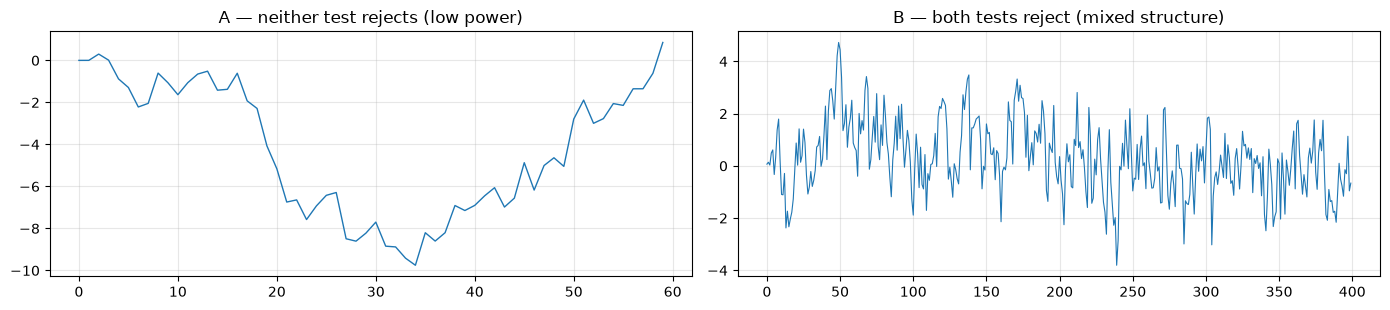

In [11]:
# Conflict A — neither rejects: near-unit-root AR(1) on a short sample (low power)
g = np.random.default_rng(7)
short = np.zeros(60)
for i in range(1, 60):
    short[i] = 0.95 * short[i - 1] + g.normal()

# Conflict B — both reject: stationary AR plus a slow stochastic level
g = np.random.default_rng(0)
mixed_ar = np.zeros(400)
for i in range(1, 400):
    mixed_ar[i] = 0.5 * mixed_ar[i - 1] + g.normal()
mixed = mixed_ar + 0.15 * np.cumsum(g.normal(size=400))

conflicts = pd.DataFrame([
    stationarity_report(short, "A: AR(1) φ=0.95, n=60"),
    stationarity_report(mixed, "B: AR(1) + slow random walk"),
])
print(conflicts.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.2))
axes[0].plot(short, lw=1); axes[0].set_title("A — neither test rejects (low power)")
axes[1].plot(mixed, lw=0.8); axes[1].set_title("B — both tests reject (mixed structure)")
plt.tight_layout()
plt.show()

- **A** (ADF p = 0.785, KPSS p = 0.073): neither rejects. With 60 points there is not enough information to separate $\phi = 0.95$ from $\phi = 1$. The honest answer is *unknown* — collect more data or decide on domain grounds.
- **B** (ADF p ≈ 0.000, KPSS p = 0.010): both reject, which is contradictory only if you assume the series is purely one or the other. It has a mean-reverting short run **and** a drifting level, so neither pure model fits. Options: fractional integration, an explicit trend/level component (state space), or differencing and accepting some over-differencing.

## 10. Residual analysis

Stationarity testing happens *before* modelling; residual diagnostics happen *after*. The target is the same process both times: **white noise**.

$$\hat{\varepsilon}_t = y_t - \hat{y}_t$$

A correctly specified model has extracted all the structure, so what is left should be unpredictable. Anything visible in the residuals is signal you failed to capture. Four checks:

1. **Residual plot** — no trend, no changing spread.
2. **Residual ACF** — all spikes inside the band.
3. **Ljung-Box test** — a formal joint test on the first $h$ autocorrelations:

$$Q(h) = T(T+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{T-k} \ \sim\ \chi^2_{h - m}$$

with $H_0$: *residuals are independently distributed*. So **$p > 0.05$ is what you want** — the opposite of the usual reading. ($m$ = number of fitted ARMA parameters; $h \approx 10$, or $2m_{\text{season}}$ for seasonal data.)

4. **Normality** (Jarque-Bera, Q-Q plot) — needed for valid **prediction intervals**, not for point forecasts.

Compare a deliberately under-specified model against a correct one.

In [12]:
bad  = SARIMAX(log_y, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0),
               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
good = SARIMAX(log_y, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

for name, fit in [("ARIMA(1,1,1) — no seasonal term", bad),
                  ("SARIMA(1,1,1)(1,1,1)[7]", good)]:
    r = fit.resid[14:]                                   # drop the state-space burn-in
    lb = acorr_ljungbox(r, lags=[7, 14, 21], return_df=True)
    jb_stat, jb_p, skew, kurt = jarque_bera(r)
    print(f"{name}")
    print(f"   AIC {fit.aic:9.1f}   resid std {r.std():.3f}")
    print("   Ljung-Box p:", {int(i): round(p, 4) for i, p in zip(lb.index, lb['lb_pvalue'])},
          "->", "white noise" if lb['lb_pvalue'].min() > 0.05 else "STRUCTURE LEFT")
    print(f"   Jarque-Bera p {jb_p:.3g}  skew {skew:+.2f}  kurtosis {kurt:.2f}\n")

ARIMA(1,1,1) — no seasonal term
   AIC     398.7   resid std 0.331
   Ljung-Box p: {7: 0.0, 14: 0.0, 21: 0.0} -> STRUCTURE LEFT
   Jarque-Bera p 1.33e-09  skew -0.26  kurtosis 4.14

SARIMA(1,1,1)(1,1,1)[7]
   AIC     -64.6   resid std 0.226
   Ljung-Box p: {7: 0.8141, 14: 0.7508, 21: 0.831} -> white noise
   Jarque-Bera p 2.54e-292  skew -0.67  kurtosis 10.07



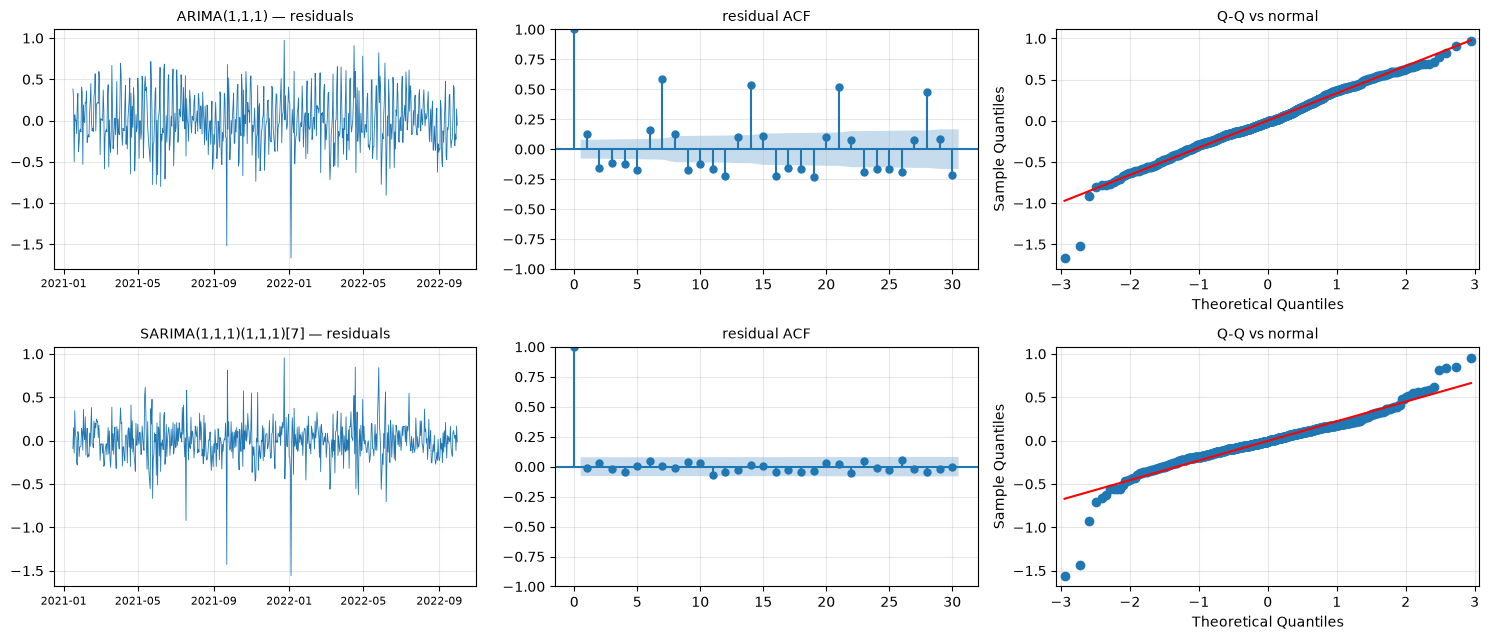

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
for i, (name, fit) in enumerate([("ARIMA(1,1,1)", bad), ("SARIMA(1,1,1)(1,1,1)[7]", good)]):
    r = fit.resid[14:]
    axes[i, 0].plot(r.index, r.values, lw=0.6)
    axes[i, 0].set_title(f"{name} — residuals", fontsize=10)
    axes[i, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    axes[i, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[i, 0].tick_params(axis="x", labelsize=8)
    plot_acf(r, lags=30, ax=axes[i, 1])
    axes[i, 1].set_title("residual ACF", fontsize=10)
    sm.qqplot(r, line="s", ax=axes[i, 2])
    axes[i, 2].set_title("Q-Q vs normal", fontsize=10)
plt.tight_layout()
plt.show()

**Results**

- **ARIMA(1,1,1)**: Ljung-Box **p = 0.0000** at every lag, and the residual ACF has unmistakable spikes at 7, 14, 21. The weekly season was never modelled, so it is sitting in the residuals. AIC 398.7.
- **SARIMA(1,1,1)(1,1,1)[7]**: Ljung-Box **p = 0.81 / 0.75 / 0.83** — comfortably above 0.05, so no detectable autocorrelation remains. Residual std falls from 0.331 to 0.226, and AIC drops to **-64.6**.

**But the residuals are still not normal.** Jarque-Bera p ≈ 2.5e-292 with **kurtosis 10.1** — very fat tails, visible as the S-curve in the Q-Q plot. This matters:

→ **Uncorrelated ≠ Gaussian.** Ljung-Box tests *autocorrelation only*. The point forecasts are fine, but **Gaussian prediction intervals will be too narrow** — extreme days occur far more often than a normal distribution allows. The fat tails come mainly from the interpolated closure days. Use empirical/bootstrapped intervals, or model the closures explicitly.

## Summary

| Concept | One line |
|---|---|
| Stationarity | mean, variance and autocovariance do not depend on $t$ |
| Why | ARMA estimates one $\mu$, $\sigma^2$, $\gamma_k$; spurious regression otherwise |
| Strict vs weak | full distribution vs first two moments; identical for Gaussian processes |
| White noise | $\gamma_k = 0 \ \forall k \neq 0$ — the residual target |
| Random walk | $\text{Var} = t\sigma^2$, shocks permanent, $\Delta y_t = \varepsilon_t$ |
| ACF vs PACF | total correlation at lag $k$ vs direct correlation with intermediate lags removed |
| Identification | AR($p$): PACF cuts at $p$. MA($q$): ACF cuts at $q$ |
| Unit root | $\phi = 1$; shocks never decay; $\phi=0.95$ is nearly indistinguishable in short samples |
| Trend-stationary | deterministic trend → **detrend** |
| Difference-stationary | stochastic trend → **difference** |
| Wrong fix | differencing a TS series → residual acf(1) ≈ -0.5 (over-differenced) |
| ADF / PP | $H_0$ = unit root; $p<0.05$ ⇒ stationary; PP breaks down on differenced series |
| KPSS | $H_0$ = stationary; $p<0.05$ ⇒ non-stationary |
| Conflicts | both fail to reject ⇒ low power; both reject ⇒ mixed structure |
| Ljung-Box | $H_0$ = independent; **$p > 0.05$ is the good outcome** |

### Five things worth remembering

1. **Plot first.** On the raw bakery series ADF and KPSS both said "stationary" while the rolling mean ran 89 → 579. The plot was right.
2. **`regression="c"` vs `"ct"` can flip the verdict** on the same data — specify the deterministic part before trusting any test.
3. **KPSS and Ljung-Box both invert the usual reading**: for those, $p > 0.05$ is the result you want.
4. **Match the fix to the trend type.** A negative lag-1 residual autocorrelation near -0.5 means you differenced when you should have detrended.
5. **Passing Ljung-Box is not passing normality.** Our final model left uncorrelated but fat-tailed (kurtosis 10) residuals — fine for point forecasts, not for Gaussian intervals.